# Análisis Exploratorio de Datos (EDA) - Medidas Agregadas
Este notebook contiene el análisis exploratorio agregado para comprender el funcionamiento general de la Red de Hospitales, de acuerdo a lo solicitado.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import sys
sys.path.append("../scripts")
import bases

# Importación opcional de contextily para mapas base
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Carga de datos
df_pacientes = pd.read_excel("../data/pacientes.xlsx")
hosp_coords = pd.read_csv("../data/hospitales_coordenadas.csv")

# Funciones de limpieza basadas en el código existente
df_pacientes = df_pacientes[df_pacientes["Id"].astype(str).str.match(r"[A-Za-z0-9]+")]
df_pacientes["Nombre Hospital"] = df_pacientes["Nombre Hospital"].str.strip().str.upper()
date_cols = ["Fecha inicio", "Fecha egreso", "Última actualización"]
for c in date_cols:
    df_pacientes[c] = pd.to_datetime(df_pacientes[c], errors="coerce")
df_pacientes["Duracion días"] = (df_pacientes["Fecha egreso"] - df_pacientes["Fecha inicio"]).dt.days

# Agregamos feature de fallecimiento
df_pacientes["murio"] = df_pacientes["Motivo"].astype(str).str.contains("fallec|muert", case=False, na=False)

# Reconstruir traslados
df_traslados = bases.reconstruir_traslados(df_pacientes)
print(f"Total registros limpios pacientes: {len(df_pacientes)}")
print(f"Total traslados reconstruidos: {len(df_traslados)}")


Total registros limpios pacientes: 7399
Total traslados reconstruidos: 496


## Mapa con los hospitales y municipios alrededor
Utilizando geopandas y las coordenadas provistas.

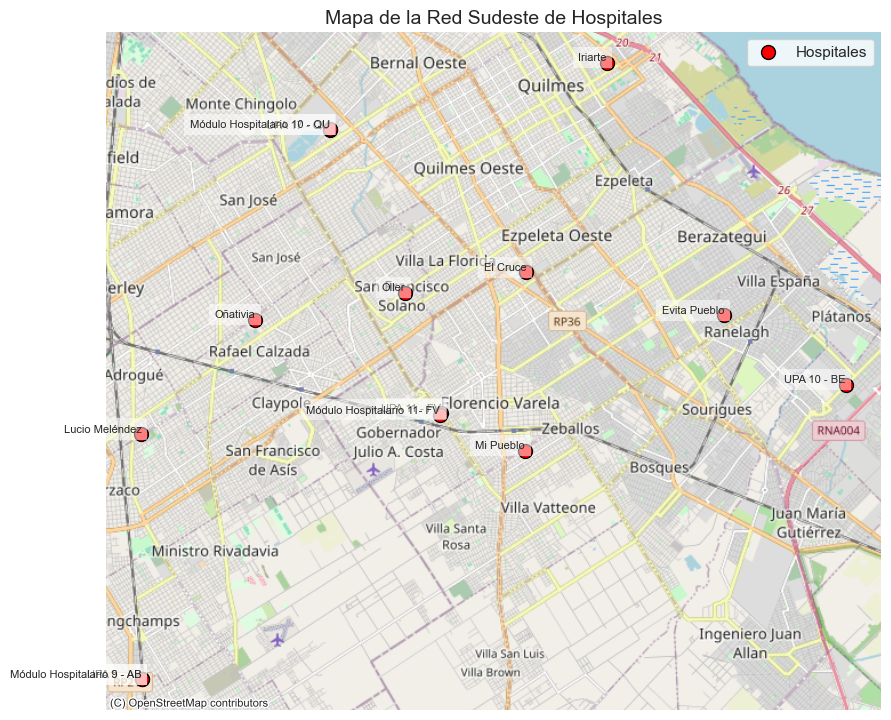

In [2]:
# Geopandas directamente desde coordenadas procesadas
gdf_hosp = gpd.GeoDataFrame(
    hosp_coords,
    geometry=gpd.points_from_xy(hosp_coords["Longitud"], hosp_coords["Latitud"]),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))
gdf_hosp_m = gdf_hosp.to_crs(epsg=3857)
gdf_hosp_m.plot(ax=ax, color="red", markersize=100, edgecolor="black", label="Hospitales")

if HAS_CTX:
    try:
        ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    except:
        pass

for x, y, label in zip(gdf_hosp_m.geometry.x, gdf_hosp_m.geometry.y, gdf_hosp_m["Nombre Hospital"]):
    ax.text(x, y, label, fontsize=8, ha="right", va="bottom", bbox=dict(facecolor="white", alpha=0.5, edgecolor="none"))

plt.title("Mapa de la Red Sudeste de Hospitales", fontsize=14)
plt.axis("off")
plt.legend()
plt.show()


## Total de traslados
Total histórico.

In [3]:
total_traslados = len(df_traslados)
print(f"El total de traslados procesados en la red fue: {total_traslados}")


El total de traslados procesados en la red fue: 496


## Cantidad de traslados en función del tiempo

C:\Users\micag\AppData\Local\Temp\ipykernel_28940\1009575794.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


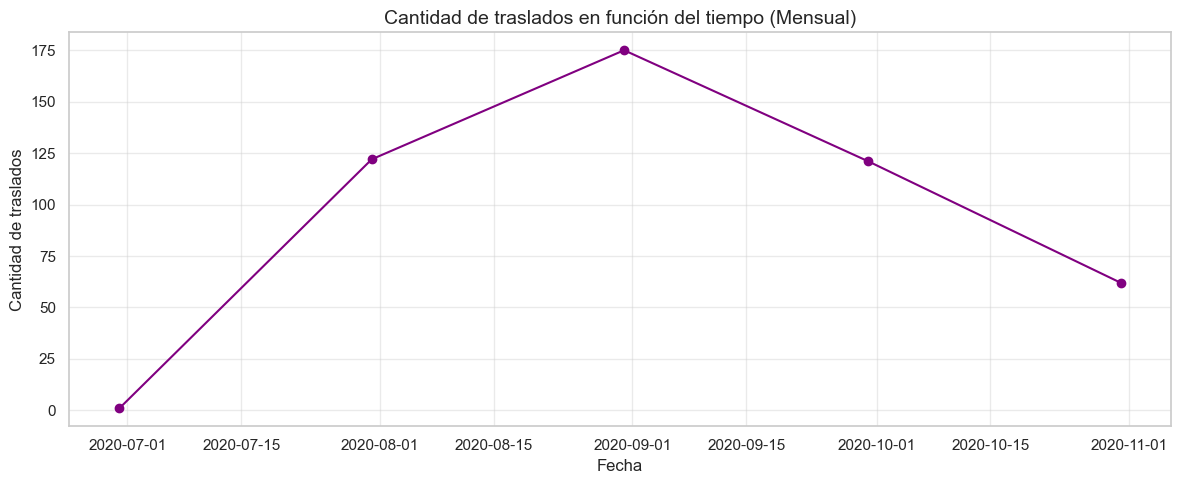

In [4]:
# Agrupamos los traslados por mes/año utilizando la fecha del egreso (que genera el traslado)
traslados_tiempo = (
    df_traslados
    .set_index("Fecha egreso")
    .resample("M")
    .size()
)

plt.figure(figsize=(12, 5))
plt.plot(traslados_tiempo.index, traslados_tiempo.values, marker="o", linestyle="-", color="purple")
plt.title("Cantidad de traslados en función del tiempo (Mensual)", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Cantidad de traslados")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Cantidad de traslados para cada persona
Promedio, desvío y distribución.

Métricas de traslados por paciente:
  - Total de pacientes trasladados: 460
  - Promedio de traslados: 1.08
  - Desvío estándar: 0.29
  - Máximo de traslados de un paciente: 3


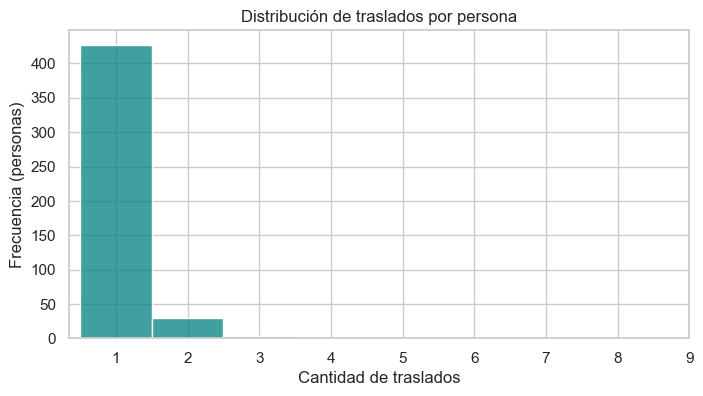

In [5]:
traslados_por_paciente = df_traslados.groupby("Id").size()

print("Métricas de traslados por paciente:")
print(f"  - Total de pacientes trasladados: {len(traslados_por_paciente)}")
print(f"  - Promedio de traslados: {traslados_por_paciente.mean():.2f}")
print(f"  - Desvío estándar: {traslados_por_paciente.std():.2f}")
print(f"  - Máximo de traslados de un paciente: {traslados_por_paciente.max()}")

plt.figure(figsize=(8, 4))
sns.histplot(traslados_por_paciente, bins=range(1, 10), discrete=True, color="teal")
plt.title("Distribución de traslados por persona")
plt.xlabel("Cantidad de traslados")
plt.ylabel("Frecuencia (personas)")
plt.xticks(range(1, 10))
plt.show()


## Tiempo dentro del sistema por persona

Promedio de tiempo en el sistema por persona: 10.14 días
Desvío estándar de tiempo en el sistema: 96.22 días


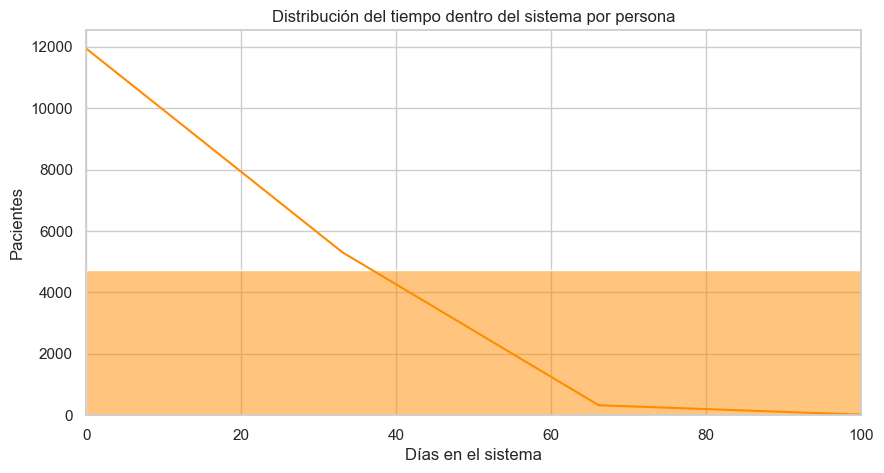

In [6]:
# Consideramos el tiempo total que estuvo una persona en el sistema (de su primera fecha inicio a su última fecha egreso)
tiempo_sistema = df_pacientes.groupby("Id").agg(
    ingreso_inicial=("Fecha inicio", "min"),
    egreso_final=("Fecha egreso", "max")
)
tiempo_sistema["dias_en_sistema"] = (tiempo_sistema["egreso_final"] - tiempo_sistema["ingreso_inicial"]).dt.days

# Filtramos outliers o datos erróneos (días negativos)
tiempo_sistema = tiempo_sistema[tiempo_sistema["dias_en_sistema"] >= 0]

print(f"Promedio de tiempo en el sistema por persona: {tiempo_sistema['dias_en_sistema'].mean():.2f} días")
print(f"Desvío estándar de tiempo en el sistema: {tiempo_sistema['dias_en_sistema'].std():.2f} días")

plt.figure(figsize=(10, 5))
sns.histplot(tiempo_sistema["dias_en_sistema"], bins=50, color="darkorange", kde=True)
plt.title("Distribución del tiempo dentro del sistema por persona")
plt.xlabel("Días en el sistema")
plt.ylabel("Pacientes")
plt.xlim(0, 100) # recorta un poco la cola para mejor visibilidad
plt.show()


## Descriptivos por hospital
Traslados (ingresos/egresos), tiempo promedio y muertes por hospital.

In [7]:
# Traslados generados (origen del traslado)
traslados_out = df_traslados.groupby("Nombre Hospital").size()
# Traslados recibidos (destino del traslado)  
traslados_in = df_traslados.groupby("Hospital siguiente").size()

# Estancia promedio por evento
estadia_promedio = df_pacientes.groupby("Nombre Hospital")["Duracion días"].mean()

# Cantidad de muertos
muertes = df_pacientes.groupby("Nombre Hospital")["murio"].sum()

# Consolidamos
desc_hospitales = pd.DataFrame({
    "Traslados (Egresados)": traslados_out,
    "Traslados (Recibidos)": traslados_in,
    "Tiempo Promedio (Días)": estadia_promedio,
    "Muertes Totales": muertes
}).fillna(0)

desc_hospitales = desc_hospitales.round(2).sort_values(by="Traslados (Egresados)", ascending=False)
display(desc_hospitales)


,Traslados (Egresados),Traslados (Recibidos),Tiempo Promedio (Días),Muertes Totales
UPA 11 - FV,133.0,23.0,1.56,5
MI PUEBLO,101.0,16.0,6.01,77
UPA 5 - AB,71.0,16.0,1.92,25
LUCIO MELÉNDEZ,63.0,24.0,9.89,91
UPA 17 - QU,28.0,5.0,73.27,0
MÓDULO HOSPITALARIO 11- FV,26.0,210.0,11.61,66
OÑATIVIA,20.0,2.0,9.01,109
IRIARTE,16.0,6.0,15.71,82
EL CRUCE,14.0,45.0,9.96,56
MÓDULO HOSPITALARIO 10 - QU,13.0,38.0,13.33,27


## Cantidad de personas con distintos niveles de riesgo social y estados (crítico, intermedio, general)

Estado al ingreso,ocupadas_covid,ocupadas_otros,sospechosos
Nivel riesgo social,,,
no,840,680,1229
si,702,183,1165


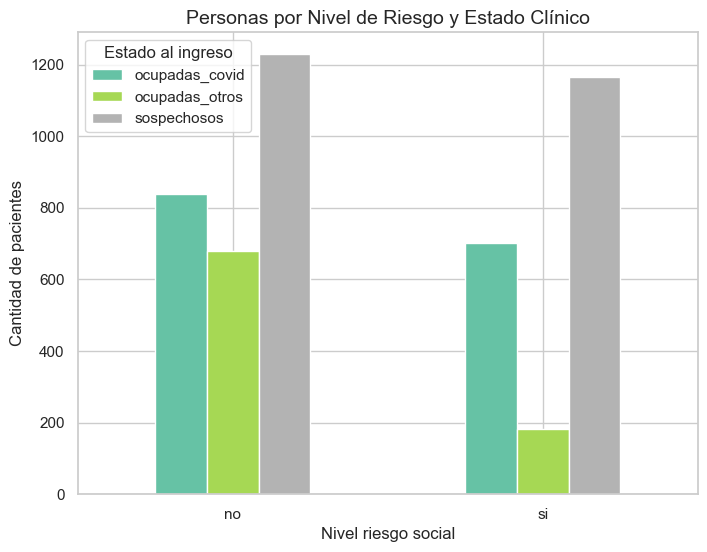

In [8]:
# Verificamos los campos disponibles en df_pacientes. Si los nombres varían ajustamos.
# Intentaremos encontrar los equivalentes a Riesgo Social y Estado al ingreso
cols = [c for c in df_pacientes.columns if 'riesgo social' in c.lower() or 'riesgo_social' in c.lower()]
col_riesgo_social = cols[0] if cols else "Nivel de riesgo"

cols_estado = [c for c in df_pacientes.columns if 'estado al ingreso' in c.lower() or 'tipo al ingreso' in c.lower()]
col_estado = cols_estado[0] if cols_estado else "Estado al ingreso"

if col_riesgo_social in df_pacientes.columns and col_estado in df_pacientes.columns:
    # Agrupamos por Id para no duplicar pacientes (tomamos su último registro)
    df_unicos = df_pacientes.sort_values("Fecha inicio").drop_duplicates("Id", keep="last")
    
    tabla_riesgo_estado = pd.crosstab(
        df_unicos[col_riesgo_social],
        df_unicos[col_estado]
    )
    display(tabla_riesgo_estado)
    
    tabla_riesgo_estado.plot(kind="bar", figsize=(8, 6), colormap="Set2")
    plt.title("Personas por Nivel de Riesgo y Estado Clínico", fontsize=14)
    plt.xlabel(col_riesgo_social)
    plt.ylabel("Cantidad de pacientes")
    plt.xticks(rotation=0)
    plt.legend(title=col_estado)
    plt.show()
else:
    print(f"Columnas no encontradas con precisión. Estructura disponible: {df_pacientes.columns.tolist()}")
